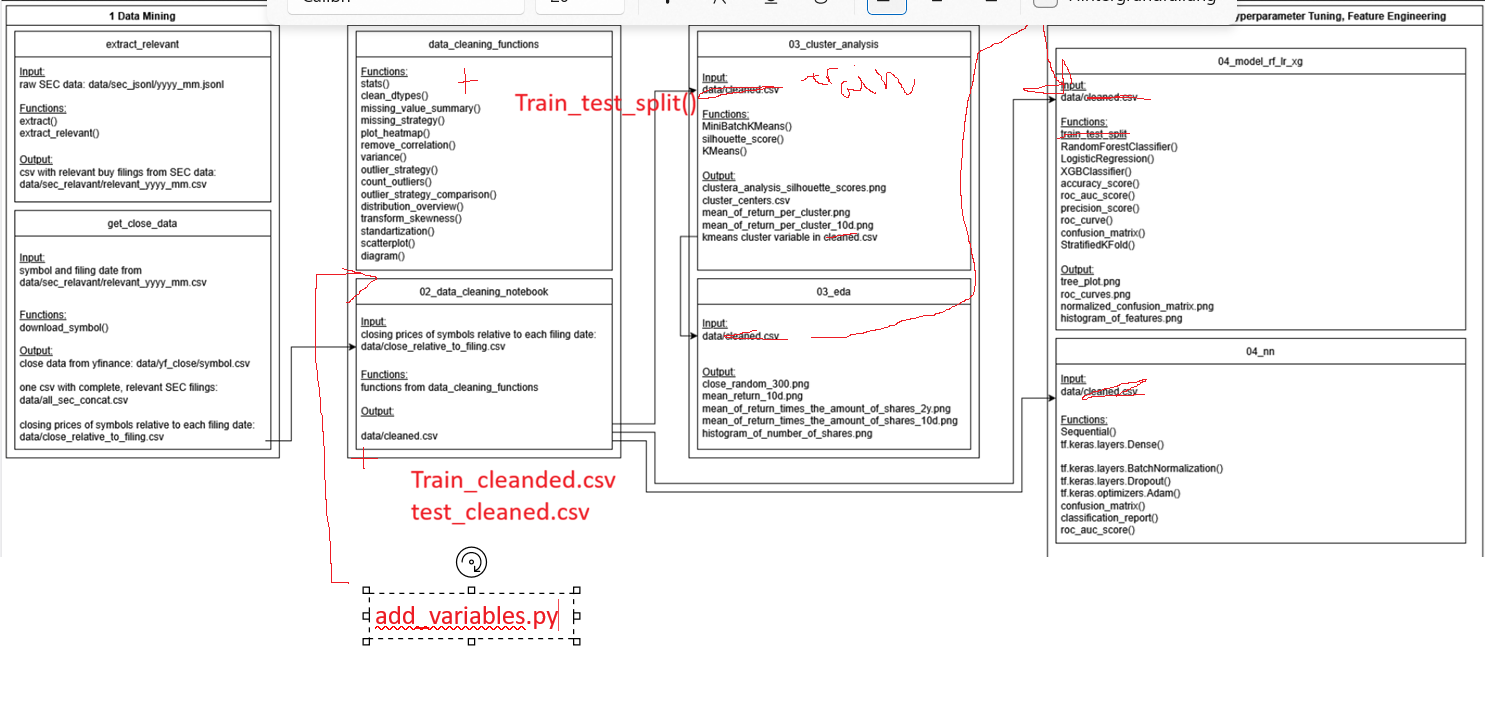

gucken ob neuer join geklappt hat und concat auch wirklich one to many und alles so passt, dann weiter mit outlier


# Data Cleaning


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
from scipy.stats import boxcox, skew, zscore
import sys
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src/02_data_preperation"))

from data_cleaning_helper import missing_strategy, plot_heatmap, skewness_overview

In [2]:
inner_close_sec_uncleaned = pd.read_csv(project_root / "data/inner_close_sec_uncleaned.csv")
inner_close_sec_uncleaned

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
0,ANTP,INZER DEBORAH,2009-01-29,1000.0,2.5000,3000.0,False,True,False,False,...,False,False,False,True,True,True,True,True,False,False
1,BLK,"MERRILL LYNCH & CO., INC.",2009-01-22,1000.0,106.0499,2332450.0,False,False,True,False,...,True,False,True,True,True,True,True,True,True,True
2,NVSL,Nimons William C,2009-01-30,200.0,5.9500,9365.0,False,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NVSL,Nimons William C,2009-01-30,200.0,5.9500,9365.0,False,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HBNC,NEFF JAMES D,2009-01-30,6000.0,12.5000,42700.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414715,ECAT,"Saba Capital Management, L.P.",2023-12-29,36118.0,16.1300,24048629.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
414716,TURN,Rendino Kevin,2023-12-29,11959.0,4.1032,720198.0,True,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
414717,TURN,Wolfe Daniel B,2023-12-28,1500.0,3.9412,238000.0,True,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
414718,TURN,Wolfe Daniel B,2023-12-29,1000.0,4.1078,239000.0,True,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
inner_close_sec_uncleaned.isnull().sum()

issuer.tradingSymbol                                           0
reportingOwner.name                                            0
transactionDate                                                0
amounts.shares                                                 0
amounts.pricePerShare                                          0
postTransactionAmounts.sharesOwnedFollowingTransaction       249
reportingOwner.relationship.isDirector                         0
reportingOwner.relationship.isOfficer                          0
reportingOwner.relationship.isTenPercentOwner                  0
reportingOwner.relationship.isOther                            0
holding_change_percent                                       249
direct_ownership                                               0
transaction_month                                              0
month_sin                                                      0
month_cos                                                      0
target_2                 

In [4]:
crtf_missing_removed = missing_strategy(inner_close_sec_uncleaned,
                      default_missing_strategy="delete",
                      except_replace_0=[],
                      except_replace_mean=[],
                      except_delete=[])
crtf_missing_removed

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
0,ANTP,INZER DEBORAH,2009-01-29,1000.0,2.5000,3000.0,False,True,False,False,...,False,False,False,True,True,True,True,True,False,False
1,BLK,"MERRILL LYNCH & CO., INC.",2009-01-22,1000.0,106.0499,2332450.0,False,False,True,False,...,True,False,True,True,True,True,True,True,True,True
4,HBNC,NEFF JAMES D,2009-01-30,6000.0,12.5000,42700.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
5,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,46700.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,659651.0,False,False,True,False,...,True,True,True,True,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414711,TPL,STAHL MURRAY,2023-12-29,3.0,1572.4500,198486.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
414712,NBBK,Ayoub Paul J.,2023-12-28,5000.0,14.0000,5000.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
414713,MPA,"Saba Capital Management, L.P.",2023-12-28,2064.0,11.5700,1899928.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
414714,ECAT,"Saba Capital Management, L.P.",2023-12-28,299702.0,16.3700,24012511.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
crtf_str_removed = crtf_missing_removed.drop(columns=["transaction_month"])

In [6]:
# saving memory
integer = ["amounts.shares"]
bools = ["direct_ownership", "target_2", "target_3", "target_4", "target_5", "target_6", "target_7", "target_8",
         "target_9", "target_10", "target_20", "target_60"]
floats = ["amounts.pricePerShare", "month_sin", "month_cos","holding_change_percent"]

for var in integer:
    crtf_str_removed[var] = crtf_str_removed[var].astype("int32")

for var in bools:
    crtf_str_removed[var] = crtf_str_removed[var].astype("bool")

for var in floats:
    crtf_str_removed[var] = crtf_str_removed[var].astype("float32")

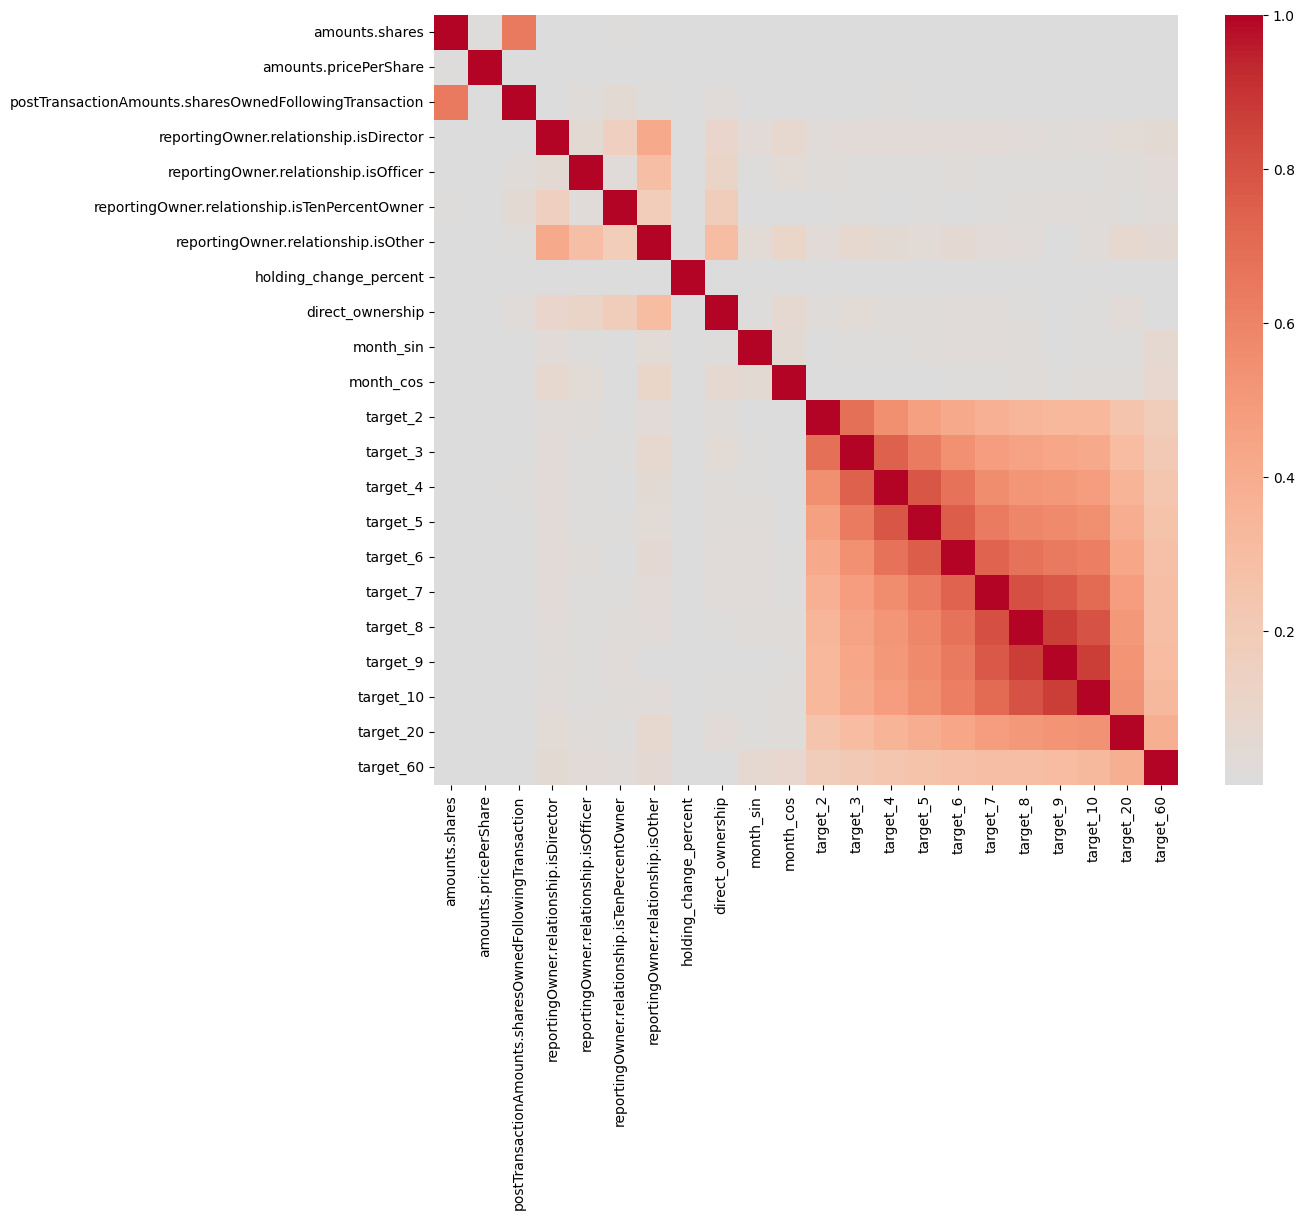

In [8]:
plot_heatmap(crtf_str_removed.select_dtypes(exclude=["object", "string"]))

# drop it later because necessairy for fearure engineering
crtf_mhighcor_removed = crtf_str_removed.drop(columns="postTransactionAmounts.sharesOwnedFollowingTransaction")

In [9]:
df = crtf_mhighcor_removed.sort_values("transactionDate")

split_date = "2020-01-01"

train_df = df[df["transactionDate"] < split_date]
test_df  = df[df["transactionDate"] >= split_date]

In [10]:
train_df


,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,holding_change_percent,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
572,BDC,Biegacki Steven,2008-10-14,30,25.500000,False,True,False,False,0.000000,...,False,False,False,False,False,False,False,False,False,False
573,BDC,Biegacki Steven,2008-10-15,100,23.569000,False,True,False,False,333.333344,...,False,False,False,False,False,False,False,False,False,False
574,BDC,Biegacki Steven,2008-10-15,100,23.190001,False,True,False,False,76.923080,...,False,False,False,False,False,False,False,False,False,False
575,BDC,Biegacki Steven,2008-10-22,200,22.750000,False,True,False,False,0.000000,...,False,False,False,False,False,False,False,False,False,False
576,BDC,Biegacki Steven,2008-10-22,100,21.500000,False,True,False,False,50.000000,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321959,PFHO,KUBOTA TOM,2019-12-31,2300,5.140000,True,True,True,False,0.117108,...,False,False,False,True,True,True,True,True,True,False
321960,MPB,Moisey Robert J,2019-12-31,156,28.799999,True,False,False,False,1.025327,...,False,False,False,False,False,False,False,False,False,False
321961,MPB,KERWIN GREGORY M,2019-12-31,35,28.799999,True,False,False,False,0.109949,...,False,False,False,False,False,False,False,False,False,False
321962,MPB,Grubic Robert C,2019-12-31,173,28.799999,True,False,False,False,0.403167,...,False,False,False,False,False,False,False,False,False,False


In [11]:
Q1 = train_df.select_dtypes(include=["integer", "float"]).quantile(0.01)
Q3 = train_df.select_dtypes(include=["integer", "float"]).quantile(0.99)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

for df in train_df.select_dtypes(include=["integer", "float"]), test_df.select_dtypes(include=["integer", "float"]):
    outlier_counts = ((df < lower) | (df > upper)).sum()
    print(outlier_counts)

amounts.shares            713
amounts.pricePerShare     544
holding_change_percent    772
month_sin                   0
month_cos                   0
dtype: int64
amounts.shares             461
amounts.pricePerShare     4443
holding_change_percent     367
month_sin                    0
month_cos                    0
dtype: int64


In [12]:
def remove_outliers(df, lower, upper):
    numeric_df = df.select_dtypes(include=["integer", "float"])
    mask = ~((numeric_df < lower) | (numeric_df > upper)).any(axis=1)
    return df[mask]

lower = train_df.select_dtypes(include=["integer", "float"]).quantile(0.01)
upper = train_df.select_dtypes(include=["integer", "float"]).quantile(0.99)

train_df = remove_outliers(train_df, lower, upper)
test_df = remove_outliers(test_df, lower, upper)

In [15]:
variances = train_df.select_dtypes(include=["integer", "float", "bool"]).var(ddof=1)
variances
variances = test_df.select_dtypes(include=["integer", "float", "bool"]).var(ddof=1)
variances

amounts.shares                                   2.130868e+09
amounts.pricePerShare                            8.676238e+02
reportingOwner.relationship.isDirector           2.253241e-01
reportingOwner.relationship.isOfficer            2.326171e-01
reportingOwner.relationship.isTenPercentOwner    1.972340e-01
reportingOwner.relationship.isOther              6.118404e-02
holding_change_percent                           7.473000e+02
direct_ownership                                 2.336442e-01
month_sin                                        5.261719e-01
month_cos                                        4.685454e-01
target_2                                         2.459347e-01
target_3                                         2.484498e-01
target_4                                         2.459141e-01
target_5                                         2.451012e-01
target_6                                         2.459798e-01
target_7                                         2.470201e-01
target_8

In [18]:
eda_df = pd.concat([train_df, test_df])
eda_df.to_csv(project_root / "data/eda_df.csv", index=False)

In [23]:
skewness_overview(train_df.select_dtypes(exclude=["bool", "object", "string"]))

,Row,original,log(x),log1p,sqrt,boxcox,power_transform
0,amounts.shares,7.658,-0.377,-0.239,3.833,-0.015,-0.013
1,amounts.pricePerShare,2.262,0.034,0.139,0.883,0.006,0.026
2,holding_change_percent,5.341,not applicable because 0 or negative value,1.437,2.642,not calculable because values smaller then 0,0.480
3,month_sin,0.167,not applicable because 0 or negative value,not calculable because values smaller then -1,not calculable because of values smaller then 0,not calculable because values smaller then 0,0.067
4,month_cos,-0.066,not applicable because 0 or negative value,not calculable because values smaller then -1,not calculable because of values smaller then 0,not calculable because values smaller then 0,-0.034


In [24]:
train_df["amounts.pricePerShare"], lam = boxcox(
    train_df["amounts.pricePerShare"]
)

test_df["amounts.pricePerShare"] = boxcox(
    test_df["amounts.pricePerShare"],
    lmbda=lam
)

train_df["amounts.pricePerShare"] = train_df["amounts.pricePerShare"].astype("float32")
test_df["amounts.pricePerShare"] = test_df["amounts.pricePerShare"].astype("float32")

pt = PowerTransformer(method='yeo-johnson', standardize=True)

train_df["holding_change_percent"] = pt.fit_transform(
    train_df[["holding_change_percent"]]
)

test_df["holding_change_percent"] = pt.transform(
    test_df[["holding_change_percent"]]
)



In [14]:
test_df

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
321842,FEIM,"Edenbrook Capital, LLC",2020-01-02,3500,10.223300,1.316645e+06,True,False,True,0.266536,...,False,False,False,False,False,False,False,False,False,False
321845,MCHX,"Edenbrook Capital, LLC",2020-01-02,1505,3.706000,5.238238e+06,False,False,True,0.028739,...,False,False,False,False,False,False,False,False,False,False
321879,FMNB,Muransky Edward,2020-01-02,231,16.230000,2.588600e+04,True,False,False,0.900409,...,False,False,False,False,False,False,False,False,False,False
321873,TRC,"DT Four Partners, LLC",2020-01-02,2357,15.850000,1.077757e+06,False,False,True,0.219174,...,True,True,True,True,False,False,False,False,True,False
321877,FMNB,Wallace Amber B,2020-01-02,12,16.230000,2.436900e+04,False,True,False,0.049267,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414498,ED,Donnley Deneen L,2023-12-29,42,90.970001,8.335245e+03,False,True,False,0.506557,...,False,False,False,False,False,False,False,False,False,False
414497,ED,HOGLUND ROBERT N,2023-12-29,150,90.970001,4.484375e+04,False,True,False,0.336518,...,False,False,False,False,False,False,False,False,False,False
414496,ED,Miller Joseph,2023-12-29,12,90.970001,1.159867e+03,False,True,False,1.068222,...,False,False,False,False,False,False,False,False,False,False
414675,SPG,Roe Peggy Fang,2023-12-29,49,143.850006,3.850000e+03,True,False,False,1.289134,...,False,False,False,False,False,False,False,False,False,False


In [25]:
scale_cols = ["amounts.shares", "amounts.pricePerShare"]
for df in train_df, test_df:
    for c in scale_cols:
        df[c] = zscore(df[c])

In [26]:
test_df

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,holding_change_percent,direct_ownership,...,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_20,target_60
321842,FEIM,"Edenbrook Capital, LLC",2020-01-02,-0.263722,-0.335493,True,False,True,-0.641228,False,...,False,False,False,False,False,False,False,False,False,False
321845,MCHX,"Edenbrook Capital, LLC",2020-01-02,-0.306940,-1.359417,False,False,True,-1.044304,False,...,False,False,False,False,False,False,False,False,False,False
321879,FMNB,Muransky Edward,2020-01-02,-0.334539,0.124806,True,False,False,-0.005211,True,...,False,False,False,False,False,False,False,False,False,False
321873,TRC,"DT Four Partners, LLC",2020-01-02,-0.288483,0.101303,False,False,True,-0.710776,True,...,True,True,True,True,False,False,False,False,True,False
321877,FMNB,Wallace Amber B,2020-01-02,-0.339284,0.124806,False,True,False,-1.003434,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414498,ED,Donnley Deneen L,2023-12-29,-0.338634,1.808444,False,True,False,-0.346988,True,...,False,False,False,False,False,False,False,False,False,False
414497,ED,HOGLUND ROBERT N,2023-12-29,-0.336294,1.808444,False,True,False,-0.546189,True,...,False,False,False,False,False,False,False,False,False,False
414496,ED,Miller Joseph,2023-12-29,-0.339284,1.808444,False,True,False,0.106136,True,...,False,False,False,False,False,False,False,False,False,False
414675,SPG,Roe Peggy Fang,2023-12-29,-0.338482,2.247430,True,False,False,0.231257,True,...,False,False,False,False,False,False,False,False,False,False


In [27]:
target_cols = [
    "target_2", "target_3", "target_4", "target_5",
    "target_6", "target_7", "target_8", "target_9",
    "target_10", "target_20", "target_60"
]

X_train = train_df.drop(columns=target_cols)
y_train = train_df[target_cols]

X_test = test_df.drop(columns=target_cols)
y_test = test_df[target_cols]


In [28]:
for t in target_cols:
    print(train_df[t].sum()/len(train_df)*100)



42.24229027080442
52.76944782402568
55.25701001308041
56.15264664050586
57.10540295080282
56.30515619377281
55.728247396770456
55.10849883761445
55.796791016216275
57.79940709769179
58.5619548640266


In [29]:
for t in target_cols:
    print(test_df[t].sum()/len(test_df)*100)

43.62090111025046
53.94235734572682
56.39523625096824
57.002001032791114
56.34359669506842
55.46249677252776
55.67389620449264
55.51736380067132
55.8078363026078
54.029499096307774
53.55344694035631


In [30]:
X_train.to_csv(project_root / "data/cleaned_X_train.csv", index=False)
X_test.to_csv(project_root / "data/cleaned_X_test.csv", index=False)
y_test.to_csv(project_root / "data/cleaned_y_test.csv", index=False)
y_train.to_csv(project_root / "data/cleaned_y_train.csv", index=False)
test_df.to_csv(project_root / "data/cleaned_test_df.csv", index=False)
train_df.to_csv(project_root / "data/cleaned_train_df.csv", index=False)